In [6]:
import sys
import numpy as np
sys.path.append("../src/")
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from generators.toy_problem_to_json import toy_problem_to_json # type: ignore[reportMissingImports]
from relaxers.quadratic_model_lin_approx import quadratic_model_lin_approx # type: ignore[reportMissingImports]
from relaxers.quadratic_lin_approx_no_surrogate import quadratic_lin_approx_no_surrogate # type: ignore[reportMissingImports]
from relaxers.quadratic_model_remove_quad import quadratic_model_remove_quad # type: ignore[reportMissingImports]
from testers.condition_number_lin_program import ( # type: ignore[reportMissingImports]
    condition_number,
    condition_number_no_bounds,
    condition_number_nes_basic
)
from relaxers.standard_form import standard_form # type: ignore[reportMissingImports]

import matplotlib.pyplot as plt

np.set_printoptions(linewidth=np.inf)

In [8]:
# Number of copies of the network in the toy system
N=5

# Whether the production and flow variables have upper bounds
F_UPPER_BOUNDS=True

# Whether the demand constraint is an equality or inequality
DEMAND_INEQUALITY=False

# Capacity / demand parameters
GAMMA=1.0
# GAMMA=3.0
LAMBD=1.0
EPS=0.1
DELTA=0.1

# Lower bounds and upper bound on pressure
LX=LP=LF=0.0
UP=0.5

# The number of linear constraints to use per quadratic constraint
LIN_CONSTRAINTS = 4

# Whether to do an inner or outer approximation
OUTER_APPROXIMATION = True

# Whether the coefficient is part of the surrogate
COEFFICIENT_SURROGATE = True

# Whether to bound the surrogates with bound constraints.
SURROGATE_BOUND_BELOW = True
SURROGATE_BOUND_ABOVE = True

# Whether to divide by lambda in an inner approximation
REMOVE_DIVISION = False

There are 49 variables, 10 equality constraints, and 96 non-bound inequality constraints
G =
[[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  1.  0. -1.  0.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  1.  0. -1.  1.  0.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  

np.float64(17.340927729124463)

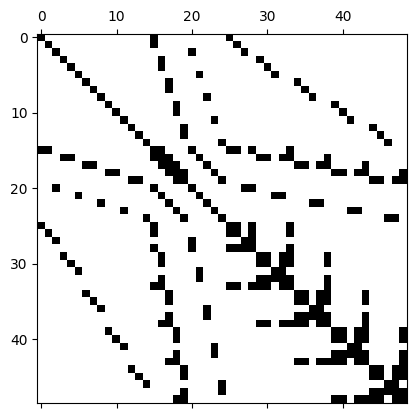

In [9]:
toy_problem_to_json(N, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                        EPS, DELTA, LP, LF, UP)
# quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
#                                 SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE)
quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION, endpoints=False)
condition_number_nes_basic(bounds=2, verbose=True)

There are 20 variables, 11 equality constraints, and 34 non-bound inequality constraints
G =
[[ 0.          1.         -1.          0.          0.          1.          0.          0.         -1.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.        ]
 [ 0.         -1.          0.          1.          1.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.         -1.         -1.          0.          0.          0.          1.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.          1.          1.          0.         -1.          0.          0.          0.          0.          0.     

np.float64(1637.6717221350987)

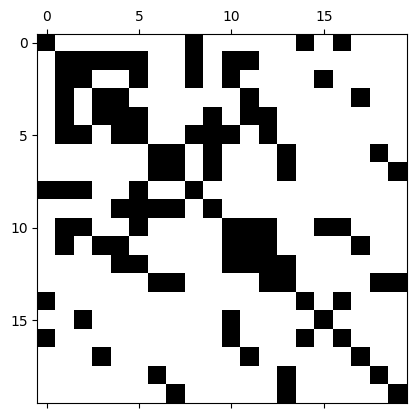

In [10]:
# quadratic_model_lin_approx(2, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
#                                 SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
#                                 f_name="model11_quad_reform_2.json", endpoints=False)
# quadratic_model_remove_quad(f_name="model11_quad_reform_nofix.json")
quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION, f_name="model11_quad_reform_nofix.json", endpoints=False)
# quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, True, f_name="model11_quad.json")
condition_number_nes_basic(bounds=2, verbose=True)